In [ ]:
%cd /home/ytee/test/trade_bot/
# https://sprott.com/insights/gold-leads-as-faith-in-fiat-falters/
from finagg.fred.api import CategorySeries, SeriesObservations,SeriesCategories,Tags
import pandas as pd
from src.csv.lbma import LBMA

so = SeriesObservations()
sc = SeriesCategories()
ret= []

def get_series(eventid):
    metadata = sc.get(eventid)
    eclass = metadata.iloc[-1]['name']
    df = so.get(eventid )[['series_id', 'value', 'date']]
    df.columns= ['event', 'actual', 'datetime']
    df['eclass'] = eclass
    df['datetime'] = pd.to_datetime(df.datetime)
    return df



/home/ytee/test/trade_bot


/home/yteevm/.local/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [15]:
gold = LBMA().get_all()['gold_am']
us10yr=  get_series('DGS10')[['datetime', 'actual']].set_index('datetime')
us2yr = get_series('DGS2')[['datetime', 'actual']].set_index('datetime')

# us2yr_m = us2yr.set_index('datetime').resample('ME').last()['actual']
# us10yr_m = us10yr.set_index('datetime').resample('ME').last()['actual']


gold.index = pd.to_datetime(gold.index)
us_spread = us10yr - us2yr

In [34]:
# gold_mret = gold.resample("M").last().pct_change()
# spread_m = us_spread.resample("M").mean()

df = pd.concat([us_spread, gold], axis=1)
df.columns = ["spread", "gold"]


In [38]:
import datetime 
df[df.index > datetime.datetime(2023,1,1)].corr()

,spread,gold
spread,1.000000,0.904586
gold,0.904586,1.000000


Text(0.5, 1.0, 'correlation 0.9045863281799726')

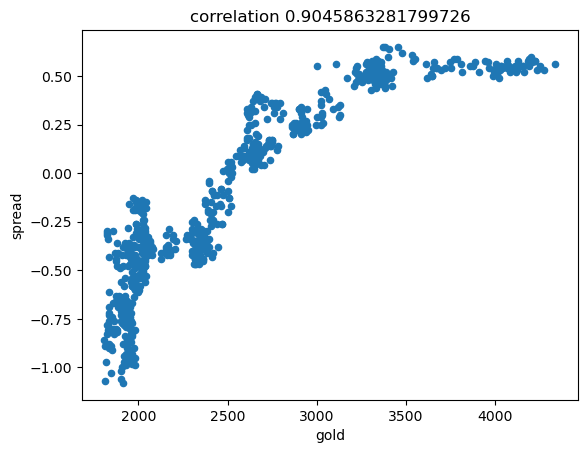

In [52]:
import datetime 
tmp = df[df.index > datetime.datetime(2023,1,1)]
ax = tmp.plot(kind='scatter', x='gold', y= 'spread')
ax.set_title('correlation %s'  % tmp.corr()['spread']['gold'])




In [ ]:
df.plot(kind='scatter', x='gold', y= 'spread')


<Axes: xlabel='gold', ylabel='spread'>

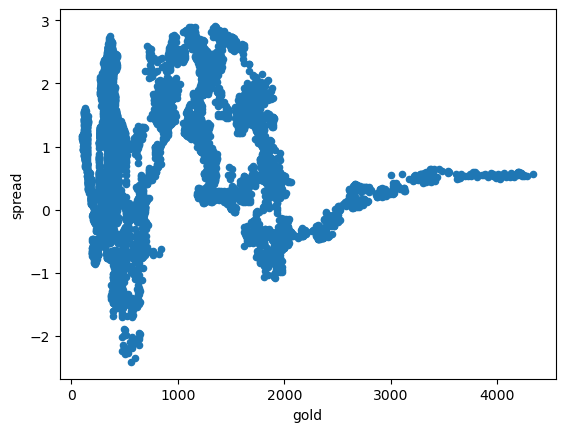

In [39]:
df.plot(kind='scatter', x='gold', y= 'spread')
